In [ ]:
!rm -rf /content/raw_data
!rm -rf /content/final_preprocessed_dataset
!mkdir /content/raw_data


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from google.colab import files as colab_files


DATASET UPLOAD

In [ ]:
uploaded = colab_files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving breast_thermography_labels.csv to breast_thermography_labels.csv
Saving Breast_Thermography_Final.zip to Breast_Thermography_Final.zip
Uploaded: ['breast_thermography_labels.csv', 'Breast_Thermography_Final.zip']


READ CSV LABELS

In [ ]:
CSV_FILE = "breast_thermography_labels.csv"
df = pd.read_csv(CSV_FILE)

print("CSV shape:", df.shape)
df.head()


CSV shape: (387, 4)


,patient_id,angle,diagnosis,label
0,IIR0001,oblleft,benign,0
1,IIR0001,anterior,benign,0
2,IIR0001,oblright,benign,0
3,IIR0002,oblright,benign,0
4,IIR0002,oblleft,benign,0


EXTRACT IMAGE DATASET

In [ ]:
def find_image_root(base="/content/raw_data"):
    for root, dirs, files in os.walk(base):
        for d in dirs:
            return os.path.join(root, d)
    return None

RAW_IMAGE_DIR = find_image_root()
print("Detected RAW_IMAGE_DIR:", RAW_IMAGE_DIR)


Detected RAW_IMAGE_DIR: /content/raw_data/breast_thermography


In [ ]:
image_lookup = {}

for root, _, filenames in os.walk(RAW_IMAGE_DIR):
    for f in filenames:
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            image_lookup[f.lower()] = os.path.join(root, f)

print("Total raw images found:", len(image_lookup))


Total raw images found: 387


IMAGE PATH MAPING

In [ ]:
def resolve_image_path(row):
    pid = row["patient_id"]
    angle = row["angle"]

    if pid.startswith("Img"):
        fname = f"{pid}.jpg"
    else:
        fname = f"{pid}_{angle}.jpg"

    return image_lookup.get(fname.lower())


In [ ]:
df["image_path"] = df.apply(resolve_image_path, axis=1)
df = df.dropna(subset=["image_path"])

print("Usable matched images:", len(df))
df.head()


Usable matched images: 387


,patient_id,angle,diagnosis,label,image_path
0,IIR0001,oblleft,benign,0,/content/raw_data/breast_thermography/Breast T...
1,IIR0001,anterior,benign,0,/content/raw_data/breast_thermography/Breast T...
2,IIR0001,oblright,benign,0,/content/raw_data/breast_thermography/Breast T...
3,IIR0002,oblright,benign,0,/content/raw_data/breast_thermography/Breast T...
4,IIR0002,oblleft,benign,0,/content/raw_data/breast_thermography/Breast T...


STRATIFIED TRAIN - TEST SPLIT(Image Lvel)

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train:", len(train_df))
print("Test :", len(test_df))


Train: 309
Test : 78


CLAHE PREPROCESSING

In [ ]:
IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    return img


SAVE PREPROCESSED DATASET

In [ ]:
BASE_DIR = "/content/final_preprocessed_dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

def save_split(split_df, out_dir):
    count = 0
    for _, row in split_df.iterrows():
        img = preprocess_image(row["image_path"])
        if img is None:
            continue

        label_dir = os.path.join(out_dir, str(row["label"]))
        os.makedirs(label_dir, exist_ok=True)

        fname = os.path.basename(row["image_path"])
        cv2.imwrite(os.path.join(label_dir, fname), img)
        count += 1

    print(f"Saved {count} images → {out_dir}")

save_split(train_df, TRAIN_DIR)
save_split(test_df, TEST_DIR)


Saved 309 images → /content/final_preprocessed_dataset/train
Saved 78 images → /content/final_preprocessed_dataset/test


DATASET CLASS DISTRIBUTION CHECK

In [ ]:
def count_images(folder):
    for cls in sorted(os.listdir(folder)):
        path = os.path.join(folder, cls)
        print(f"Class {cls}: {len(os.listdir(path))} images")

print("TRAIN SET")
count_images(TRAIN_DIR)

print("\nTEST SET")
count_images(TEST_DIR)


TRAIN SET
Class 0: 201 images
Class 1: 84 images
Class 2: 24 images

TEST SET
Class 0: 51 images
Class 1: 21 images
Class 2: 6 images


DATASET VISUALIZATION

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

random.seed(42)

def pick_one_per_class(base_dir, classes=("0", "1", "2")):
    selected = {}
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        if os.path.exists(cls_path) and len(os.listdir(cls_path)) > 0:
            selected[cls] = random.choice(os.listdir(cls_path))
    return selected


def visualize_6_images(train_dir, test_dir):
    classes = ["0", "1", "2"]

    train_imgs = pick_one_per_class(train_dir, classes)
    test_imgs  = pick_one_per_class(test_dir, classes)

    plt.figure(figsize=(12, 6))

    # TRAIN row
    for i, cls in enumerate(classes):
        if cls in train_imgs:
            path = os.path.join(train_dir, cls, train_imgs[cls])
            img = cv2.imread(path, 0)

            plt.subplot(2, 3, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"TRAIN | Class {cls}")
            plt.axis("off")

    # TEST row
    for i, cls in enumerate(classes):
        if cls in test_imgs:
            path = os.path.join(test_dir, cls, test_imgs[cls])
            img = cv2.imread(path, 0)

            plt.subplot(2, 3, i + 4)
            plt.imshow(img, cmap="gray")
            plt.title(f"TEST  | Class {cls}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


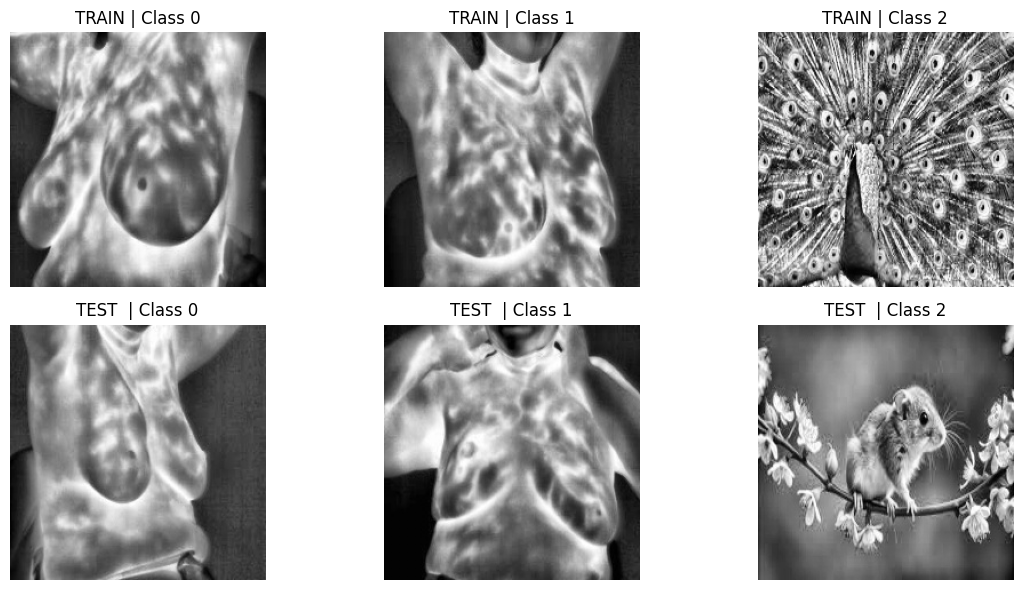

In [ ]:
visualize_6_images(TRAIN_DIR, TEST_DIR)


**PART 2**

In [ ]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


LOAD ALL IMAGES INTO MEMORY FOR FEATURE EXTRACTION

In [ ]:
IMG_SIZE = 224
DATASET_PATH = "/content/final_preprocessed_dataset"

def load_images_and_labels(base_path):
    images, labels = [], []

    for cls in sorted(os.listdir(os.path.join(base_path, "train"))):
        cls_path = os.path.join(base_path, "train", cls)
        for f in os.listdir(cls_path):
            img = cv2.imread(os.path.join(cls_path, f), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(int(cls))

    for cls in sorted(os.listdir(os.path.join(base_path, "test"))):
        cls_path = os.path.join(base_path, "test", cls)
        for f in os.listdir(cls_path):
            img = cv2.imread(os.path.join(cls_path, f), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(int(cls))

    return np.array(images), np.array(labels)


In [ ]:
X_gray, y = load_images_and_labels(DATASET_PATH)
print(X_gray.shape, y.shape)


(387, 224, 224) (387,)


HANDCRAFTED FEATURE EXTRACTION

In [ ]:
def canny_edge(img):
    return cv2.Canny(img, 50, 150)

def holistic_canny(img):
    edges = canny_edge(img)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    return cv2.dilate(edges, kernel)

def gabor_filters(img):
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    outputs = []

    for theta in thetas:
        kernel = cv2.getGaborKernel((21,21), 5.0, theta, 6.0, 0.5, 0)
        gabor = cv2.filter2D(img, cv2.CV_32F, kernel)
        gabor = cv2.normalize(gabor, None, 0, 255, cv2.NORM_MINMAX)
        outputs.append(gabor)

    return outputs


HANDCRAFTED FEATURE VISULAIZATION

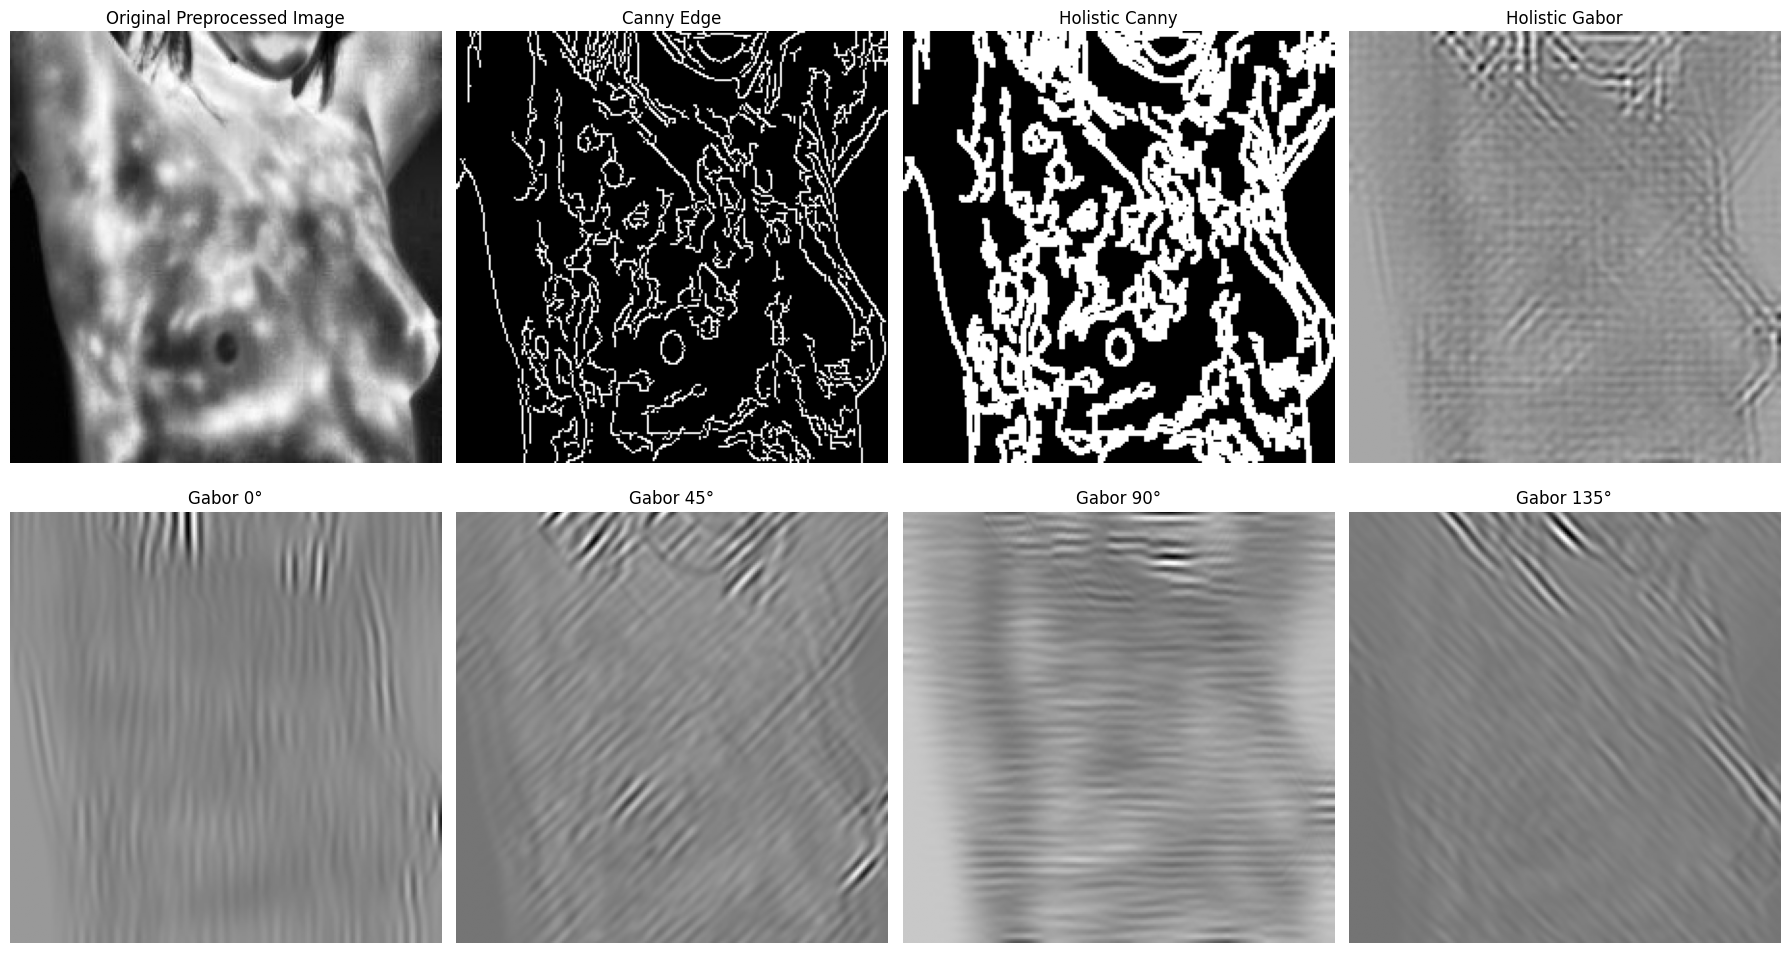

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# pick one random image from dataset
idx = random.randint(0, len(X_gray) - 1)
img = X_gray[idx]

# apply handcrafted feature extraction
canny_img = canny_edge(img)
holistic_canny_img = holistic_canny(img)
gabor_outputs = gabor_filters(img)

# holistic gabor (mean fusion)
holistic_gabor = np.mean(gabor_outputs, axis=0).astype(np.uint8)

angles = [0, 45, 90, 135]

plt.figure(figsize=(18, 10))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Preprocessed Image")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(canny_img, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(holistic_canny_img, cmap="gray")
plt.title("Holistic Canny")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(holistic_gabor, cmap="gray")
plt.title("Holistic Gabor")
plt.axis("off")

for i, gabor in enumerate(gabor_outputs):
    plt.subplot(2, 4, 5 + i)
    plt.imshow(gabor, cmap="gray")
    plt.title(f"Gabor {angles[i]}°")
    plt.axis("off")

plt.tight_layout()
plt.show()


DOWNLOAD AS ZIP FILE

In [ ]:
import os, zipfile, cv2
import numpy as np

OUT_DIR = "/content/handcrafted_visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

angles = [0, 45, 90, 135]
thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]

for idx, img in enumerate(X_gray):
    base = os.path.join(OUT_DIR, f"img_{idx:04d}")
    os.makedirs(base, exist_ok=True)

    # Original
    cv2.imwrite(f"{base}/original.png", img)

    # Canny + Holistic Canny
    canny = cv2.Canny(img, 50, 150)
    cv2.imwrite(f"{base}/canny.png", canny)
    cv2.imwrite(
        f"{base}/holistic_canny.png",
        cv2.dilate(canny, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)))
    )

    # Gabor filters
    gabors = []
    for ang, th in zip(angles, thetas):
        k = cv2.getGaborKernel((21,21), 5.0, th, 6.0, 0.5, 0)
        g = cv2.normalize(cv2.filter2D(img, cv2.CV_32F, k),
                           None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        cv2.imwrite(f"{base}/gabor_{ang}.png", g)
        gabors.append(g)

    # Holistic Gabor
    cv2.imwrite(f"{base}/holistic_gabor.png",
                np.mean(gabors, axis=0).astype(np.uint8))

# Zip everything
zip_path = "/content/handcrafted_visualizations.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT_DIR):
        for f in files:
            z.write(os.path.join(root, f),
                    arcname=os.path.relpath(os.path.join(root, f), OUT_DIR))

print("✅ Handcrafted features saved and zipped")


✅ Handcrafted features saved and zipped


IMAGE FUSION

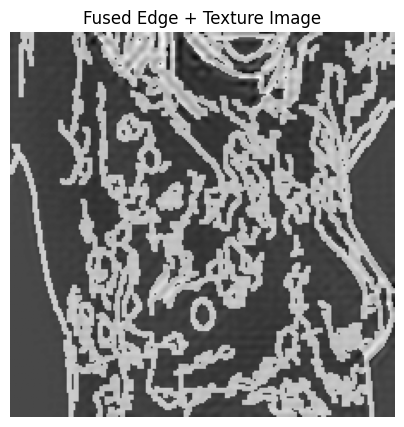

In [ ]:
# ---------- IMAGE FUSION (FIXED) ----------
edge_norm = cv2.normalize(holistic_canny_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gabor_norm = cv2.normalize(holistic_gabor, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fused_image = cv2.addWeighted(edge_norm, 0.5, gabor_norm, 0.5, 0)

plt.figure(figsize=(5,5))
plt.imshow(fused_image, cmap='gray')
plt.title("Fused Edge + Texture Image")
plt.axis("off")
plt.show()

EXTRACT HANDCRAFTED FEATURE MATRIX

In [ ]:
from skimage.feature import hog

def extract_handcrafted_features_single(img):
    """
    img: single grayscale image (224,224)
    returns: 1D feature vector
    """

    # --- Edge features ---
    canny = cv2.Canny(img, 50, 150)

    # --- Texture (Gabor) ---
    gabor_maps = gabor_filters(img)
    gabor_avg = np.mean(gabor_maps, axis=0).astype(np.uint8)

    # --- Fusion ---
    canny_n = cv2.normalize(canny, None, 0, 255, cv2.NORM_MINMAX)
    gabor_n = cv2.normalize(gabor_avg, None, 0, 255, cv2.NORM_MINMAX)
    fused = cv2.addWeighted(canny_n, 0.5, gabor_n, 0.5, 0)

    # --- HOG on fused image ---
    hog_feat = hog(
        fused,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    return hog_feat


In [ ]:
handcrafted_features = []

for img in X_gray:
    feat = extract_handcrafted_features_single(img)
    handcrafted_features.append(feat)

handcrafted_features = np.array(handcrafted_features)

print("✅ Handcrafted feature matrix shape:", handcrafted_features.shape)


✅ Handcrafted feature matrix shape: (387, 6084)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features
scaler = StandardScaler()
X_handcrafted_scaled = scaler.fit_transform(handcrafted_features)

# PCA (retain 95% variance)
pca_hand = PCA(n_components=0.95, random_state=42)
X_handcrafted_pca = pca_hand.fit_transform(X_handcrafted_scaled)

print("After PCA:", X_handcrafted_pca.shape)


After PCA: (387, 300)


CONVERT GRAYSCALE TO RGB

In [ ]:
# Convert grayscale → 3-channel RGB
X_rgb = np.stack([X_gray, X_gray, X_gray], axis=-1)

print("RGB shape:", X_rgb.shape)  # (387, 224, 224, 3)


RGB shape: (387, 224, 224, 3)


**PART 3.1**

RESNET50 FEATURE EXTRACTION

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # global average pooling
    input_shape=(224, 224, 3)
)

resnet_model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

resnet_model.trainable = False
print("✅ ResNet50 loaded as feature extractor")


✅ ResNet50 loaded as feature extractor


RESNET FEATURE SCALING

In [ ]:
# Preprocess images for ResNet
X_resnet = preprocess_input(X_rgb.astype(np.float32))

# Extract deep features
resnet_features = resnet_model.predict(
    X_resnet,
    batch_size=16,
    verbose=1
)

print("ResNet50 feature shape:", resnet_features.shape)


25/25 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step
ResNet50 feature shape: (387, 2048)


RESNET PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize deep features
scaler_resnet = StandardScaler()
resnet_scaled = scaler_resnet.fit_transform(resnet_features)

# PCA (retain 95% variance)
pca_resnet = PCA(n_components=0.95, random_state=42)
X_resnet_pca = pca_resnet.fit_transform(resnet_scaled)

print("ResNet50 after PCA:", X_resnet_pca.shape)


ResNet50 after PCA: (387, 227)


**PART 3.2**

MOBILENETV2 FEATURE EXTRACTION

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

mobilenet_base.trainable = False

X_mobilenet = preprocess_input(X_rgb.astype(np.float32))

mobilenet_features = mobilenet_base.predict(
    X_mobilenet,
    batch_size=16,
    verbose=1
)

print("MobileNet feature shape:", mobilenet_features.shape)


25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 638ms/step
MobileNet feature shape: (387, 1280)


MOBILENET FEATURE SCALING AND PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_mob = StandardScaler()
mob_scaled = scaler_mob.fit_transform(mobilenet_features)

pca_mob = PCA(n_components=0.95, random_state=42)
X_mobilenet_pca = pca_mob.fit_transform(mob_scaled)

print("MobileNet after PCA:", X_mobilenet_pca.shape)


MobileNet after PCA: (387, 237)


HYBRID FEATURE FUSION

In [ ]:
X_fused = np.concatenate([
    X_handcrafted_pca,
    X_resnet_pca,
    X_mobilenet_pca
], axis=1)

print("Final fused feature shape:", X_fused.shape)


Final fused feature shape: (387, 764)


TRAIN - TEST SPLIT (FEATURE LEVEL)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fused,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(309, 764) (78, 764)


SVM CLASSIFICATION

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_clf = SVC(
    kernel='rbf',      # base paper commonly uses RBF
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("✅ SVM Accuracy:", acc)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ SVM Accuracy: 0.8205128205128205

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88        51
           1       1.00      0.33      0.50        21
           2       1.00      1.00      1.00         6

    accuracy                           0.82        78
   macro avg       0.93      0.78      0.79        78
weighted avg       0.86      0.82      0.79        78


Confusion Matrix:
 [[51  0  0]
 [14  7  0]
 [ 0  0  6]]


**Part 4.1**

SVM MODEL TRAINING WITH SMOTE AND HYPERPARAMETER TUNING

TRAIN AND TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)


APPLY SMOTE ONLY ON TRAINING DATA

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Balanced Train distribution:", np.bincount(y_train_balanced))
print("Test distribution (unchanged):", np.bincount(y_test))



After SMOTE:
Balanced Train distribution: [202 202 202]
Test distribution (unchanged): [50 51 51]


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_fused, y)

print("After SMOTE:", np.bincount(y_balanced))


After SMOTE: [252 252 252]


GRIDSEARCH SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


FINAL EVALUTION

In [ ]:
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC-AUC:", auc)


Accuracy: 0.9671052631578947
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        50
           1       0.98      0.92      0.95        51
           2       1.00      1.00      1.00        51

    accuracy                           0.97       152
   macro avg       0.97      0.97      0.97       152
weighted avg       0.97      0.97      0.97       152

[[49  1  0]
 [ 4 47  0]
 [ 0  0 51]]
ROC-AUC: 0.9877072413123665


**PART 4.2**

TEST - TRAIN SPLIT FOR GRAD CAM

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create indices
indices = np.arange(len(X_gray))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split grayscale
X_train_gray = X_gray[train_idx]
X_test_gray  = X_gray[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

print("Train:", X_train_gray.shape)
print("Test :", X_test_gray.shape)


Train: (309, 224, 224)
Test : (78, 224, 224)


CONVERT IMAGES TO RGB

In [ ]:
X_test_rgb = np.stack([X_test_gray, X_test_gray, X_test_gray], axis=-1)

print("X_test_rgb shape:", X_test_rgb.shape)


X_test_rgb shape: (78, 224, 224, 3)


LOAD RESNET FOR GRAD-CAM

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = GlobalAveragePooling2D()(base_resnet.output)

resnet_model = Model(
    inputs=base_resnet.input,
    outputs=x
)


CREATE MODIFIED MODEL FOR GRAD-CAM

In [ ]:
last_conv_layer_name = "conv5_block3_out"

grad_model = Model(
    inputs=base_resnet.input,
    outputs=[
        base_resnet.get_layer(last_conv_layer_name).output,
        resnet_model.output
    ]
)


GENERATE GRAD-CAM HEATMAP(ATTENTION MAPPING COMPUTATION)

In [ ]:
import numpy as np
import cv2

def make_gradcam_heatmap(img_array):

    img_array = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


VISUALIZE CANCER PATIENT HOTSPOT REGION

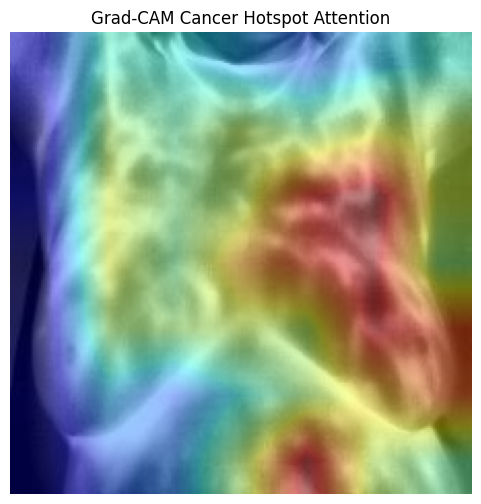

In [ ]:
import matplotlib.pyplot as plt

# choose test sample index
index = 5

sample_img = X_test_rgb[index]
img_array = np.expand_dims(sample_img, axis=0)

heatmap = make_gradcam_heatmap(img_array)

# Resize heatmap
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

# Overlay
plt.figure(figsize=(6,6))
plt.imshow(sample_img.astype("uint8"))
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Cancer Hotspot Attention")
plt.axis("off")
plt.show()


BATCH GENERATION,SAVING AND DOWNLOADING OF GRAD-CAM CANCER HOTSPOT IMAGES

In [ ]:
import os
import cv2
import numpy as np
import zipfile
from google.colab import files

SAVE_DIR = "/content/accurate_cancer_hotspots"
os.makedirs(SAVE_DIR, exist_ok=True)

count = 0

for i in range(len(X_test_rgb)):

    # Only Class 1 (Cancer)
    if y_test[i] == 1:

        sample_img = X_test_rgb[i]
        img_array = np.expand_dims(sample_img, axis=0)

        heatmap = make_gradcam_heatmap(img_array)

        # Resize heatmap
        heatmap = cv2.resize(heatmap, (224,224))

        # Normalize heatmap
        heatmap = heatmap / np.max(heatmap)

        # Threshold for strong hotspot (top 30% activation)
        threshold = 0.7
        binary_map = np.uint8(heatmap > threshold)

        # Find contours of hotspot
        contours, _ = cv2.findContours(binary_map,
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        overlay = sample_img.copy().astype("uint8")

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(overlay, (x, y), (x+w, y+h), (255,0,0), 2)

        # Apply color heatmap overlay
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(overlay, 0.6, heatmap_color, 0.4, 0)

        # Save
        cv2.imwrite(os.path.join(SAVE_DIR, f"class1_hotspot_{count}.png"), overlay)
        count += 1

print(f"✅ Saved {count} accurate cancer hotspot images.")

# Zip
zip_path = "/content/accurate_cancer_hotspots.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for file in os.listdir(SAVE_DIR):
        z.write(os.path.join(SAVE_DIR, file), arcname=file)

print("✅ Zip file created.")

# Download
files.download(zip_path)


✅ Saved 24 accurate cancer hotspot images.
✅ Zip file created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CONFUSION MATRIX - BASELINE SVM MODEL

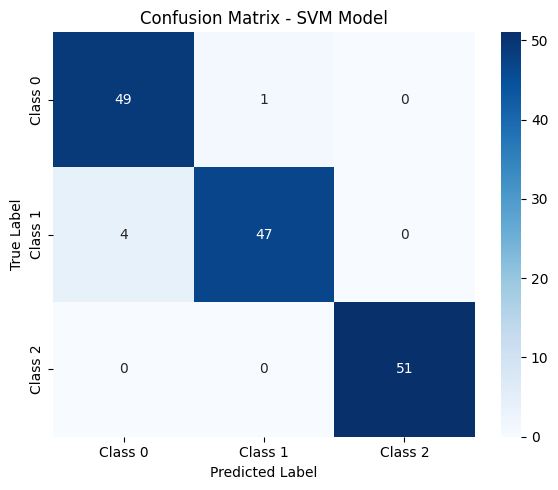

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")
plt.tight_layout()
plt.show()


CONFUSION MATRIX- PROPOSED HYBRID SVM MODEL

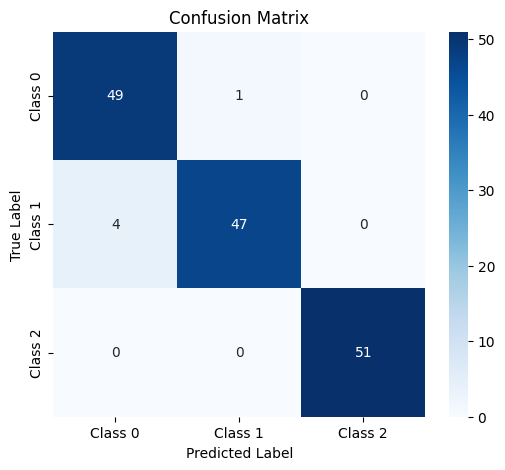

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0','Class 1','Class 2'],
            yticklabels=['Class 0','Class 1','Class 2'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


ROC CURV( MULTI-CLASS)

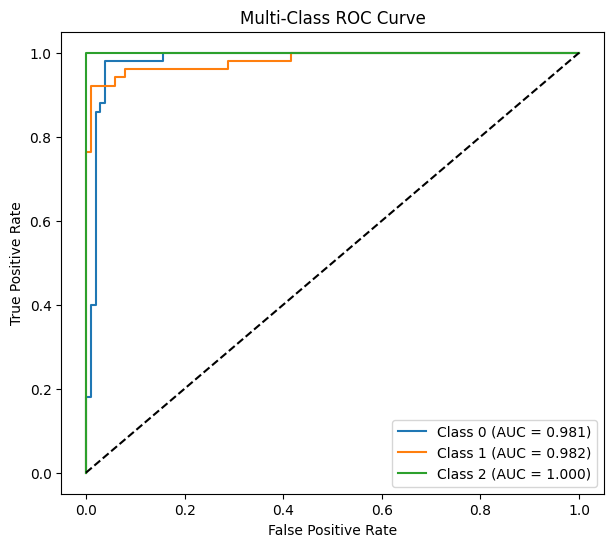

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
classes = [0,1,2]
y_test_bin = label_binarize(y_test, classes=classes)

# Compute ROC for each class
plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


ROC Curve – Class 0

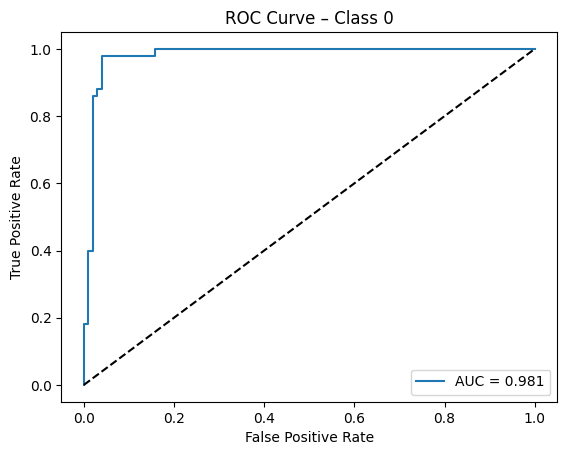

In [ ]:
fpr0, tpr0, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
auc0 = auc(fpr0, tpr0)

plt.figure()
plt.plot(fpr0, tpr0, label=f'AUC = {auc0:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 0")
plt.legend(loc="lower right")
plt.show()


ROC Curve – Class 1

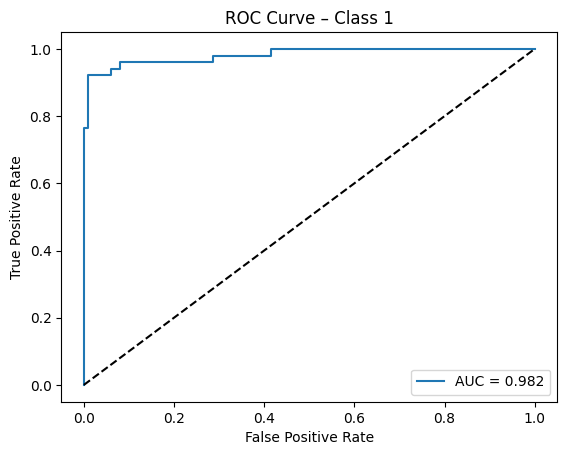

In [ ]:
fpr1, tpr1, _ = roc_curve(y_test_bin[:, 1], y_prob[:, 1])
auc1 = auc(fpr1, tpr1)

plt.figure()
plt.plot(fpr1, tpr1, label=f'AUC = {auc1:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 1")
plt.legend(loc="lower right")
plt.show()


ROC Curve – Class 2

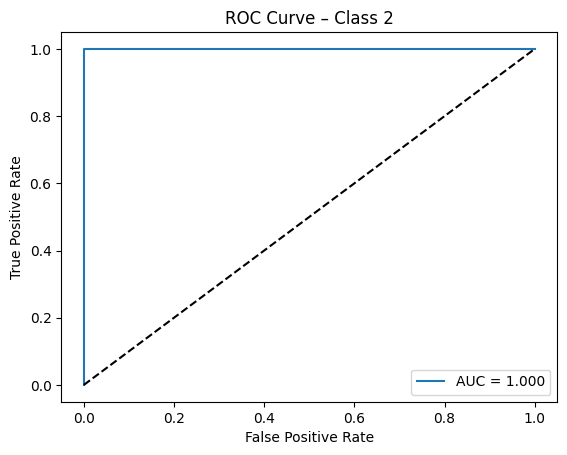

In [ ]:
fpr2, tpr2, _ = roc_curve(y_test_bin[:, 2], y_prob[:, 2])
auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr2, tpr2, label=f'AUC = {auc2:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Class 2")
plt.legend(loc="lower right")
plt.show()


ACCURACY COMAPARISON BAR GRAPH

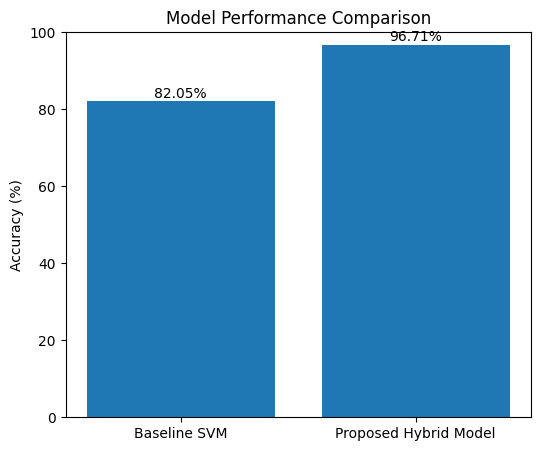

In [ ]:
import matplotlib.pyplot as plt

models = ['Baseline SVM', 'Proposed Hybrid Model']
accuracies = [82.05, 96.71]   # Your real accuracies

plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")
plt.ylim(0,100)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 1,
             f'{height:.2f}%',
             ha='center')

plt.show()


PCA VARIENCE CURV FOR ALL

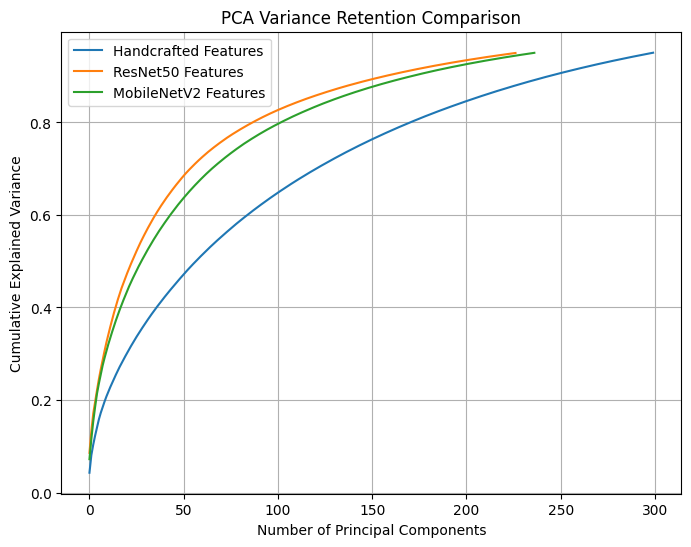

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Handcrafted
plt.plot(
    np.cumsum(pca_hand.explained_variance_ratio_),
    label="Handcrafted Features"
)

# ResNet
plt.plot(
    np.cumsum(pca_resnet.explained_variance_ratio_),
    label="ResNet50 Features"
)

# MobileNet
plt.plot(
    np.cumsum(pca_mob.explained_variance_ratio_),
    label="MobileNetV2 Features"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Retention Comparison")
plt.legend()
plt.grid(True)

plt.show()


PCA CURV FOR HANDCRAFTED FEATURES

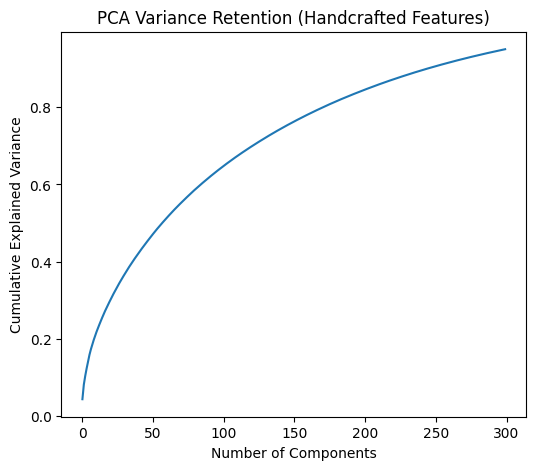

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))
plt.plot(np.cumsum(pca_hand.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Retention (Handcrafted Features)")
plt.show()


PCA CURV FOR RESNET50 FEATURES

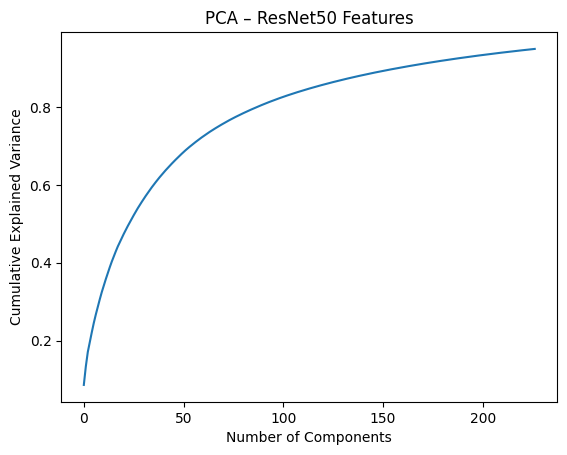

In [ ]:
plt.figure()
plt.plot(np.cumsum(pca_resnet.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – ResNet50 Features")
plt.show()


PCA CURV FOR MOBILENETV2 FEATURES

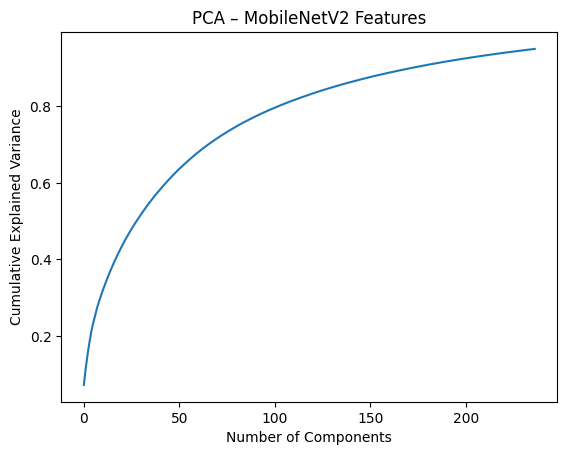

In [ ]:
plt.figure()
plt.plot(np.cumsum(pca_mob.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – MobileNetV2 Features")
plt.show()


GRAD-CAM VISUALIZE

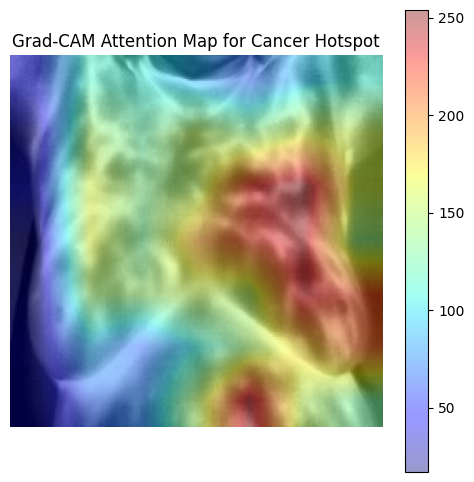

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(sample_img.astype("uint8"))
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.colorbar()
plt.title("Grad-CAM Attention Map for Cancer Hotspot")
plt.axis("off")
plt.savefig("gradcam_result.png", dpi=300, bbox_inches='tight')
plt.show()


DATASET EXTRACTION

In [ ]:
!unzip -o Breast_Thermography_Final.zip -d /content/raw_data


Archive:  Breast_Thermography_Final.zip
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Diagnostics.xlsx  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0018/IIR0018_anterior.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0018/IIR0018_oblleft.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0018/IIR0018_oblright.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0013/IIR0013_anterior.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0013/IIR0013_oblleft.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0013/IIR0013_oblright.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0113/IIR0113_oblleft.jpg  
  inflating: /content/raw_data/breast_thermography/Breast Thermography/Benign/IIR0113/IIR0113_anterior.jpg  
 